<a href="https://colab.research.google.com/github/hafeezahmad99/Form-Validation/blob/main/Ready_to_Submit_code_of_TinyCNN_%2B_LSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🖥️ System Info
Device       : cpu
CPU Cores    : 2
RAM Usage    : 1.87 GB / 13.61 GB
OS           : Linux 6.1.123+
Python Ver   : 3.11.13
Environment  : Colab
📊 Starting Training...

📈 Epoch 01 | 🕒 95.20s | Train Loss: 1.0461 | Val Loss: 0.6877 | Test Loss: 0.6757 | Train Acc: 0.5991 | Val Acc: 0.7399 | Test Acc: 0.7457
📈 Epoch 02 | 🕒 97.29s | Train Loss: 0.5836 | Val Loss: 0.4980 | Test Loss: 0.5071 | Train Acc: 0.7794 | Val Acc: 0.8089 | Test Acc: 0.8015
📈 Epoch 03 | 🕒 98.94s | Train Loss: 0.4760 | Val Loss: 0.4125 | Test Loss: 0.4252 | Train Acc: 0.8193 | Val Acc: 0.8474 | Test Acc: 0.8424
📈 Epoch 04 | 🕒 98.17s | Train Loss: 0.4208 | Val Loss: 0.3786 | Test Loss: 0.3917 | Train Acc: 0.8409 | Val Acc: 0.8582 | Test Acc: 0.8555
📈 Epoch 05 | 🕒 97.79s | Train Loss: 0.3823 | Val Loss: 0.3486 | Test Loss: 0.3687 | Train Acc: 0.8578 | Val Acc: 0.8687 | Test Acc: 0.8607
📈 Epoch 06 | 🕒 94.18s | Train Loss: 0.3493 | Val Loss: 0.3097 | Test Loss: 0.3229 | Train Acc: 0.8702 | Val Acc: 0.8850 | 

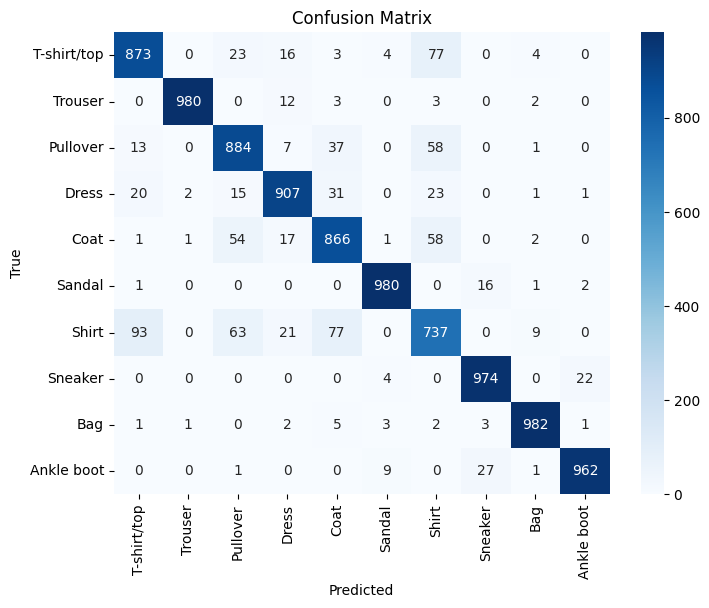

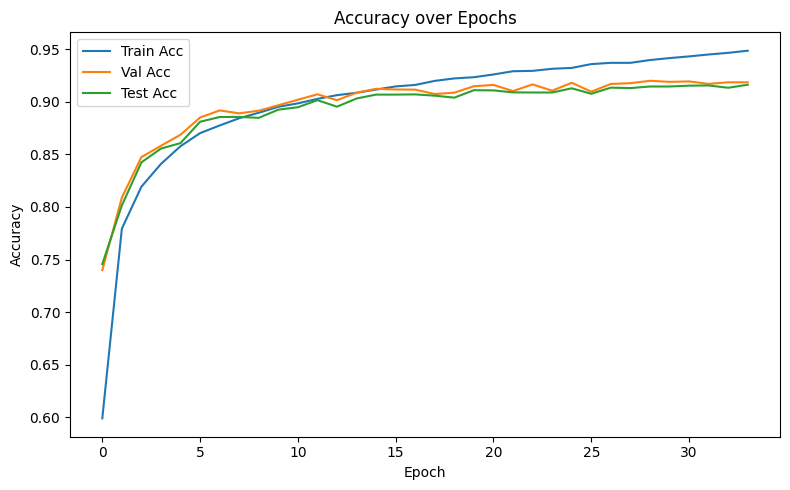

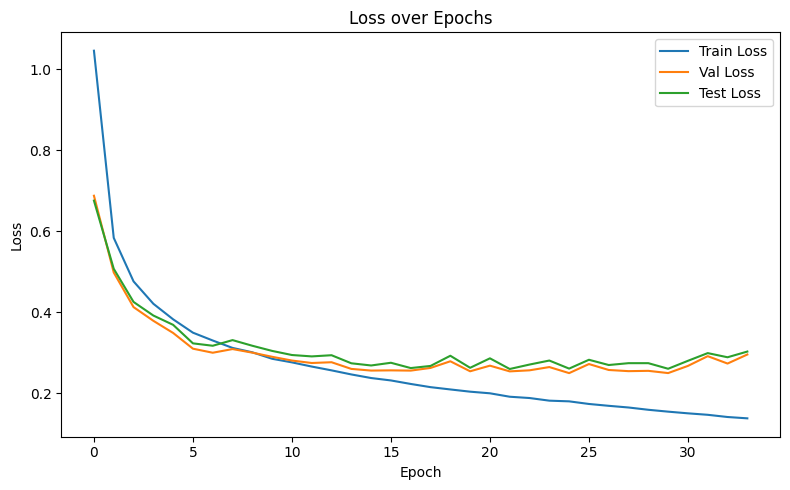


🕒 Runtime Summary
Total Training Time     : 3228.88 seconds
Average Epoch Time      : 111.34 seconds
Inference Time / Sample : 0.77 ms
Early Stopping Epoch    : 29


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time, platform, psutil, os, random
import numpy as np

# 🔒 Set random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# System Info
print("🖥️ System Info")
print(f"Device       : {device}")
if torch.cuda.is_available():
    print(f"GPU Name     : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"CPU Cores    : {os.cpu_count()}")
print(f"RAM Usage    : {psutil.virtual_memory().used / 1e9:.2f} GB / {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"OS           : {platform.system()} {platform.release()}")
print(f"Python Ver   : {platform.python_version()}")
print(f"Environment  : Colab" if "COLAB_GPU" in os.environ else "Local or Other\n")

# Dataset
transform = transforms.Compose([transforms.ToTensor()])
full_train = datasets.FashionMNIST(root='.', train=True, transform=transform, download=True)
test_ds = datasets.FashionMNIST(root='.', train=False, transform=transform)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size

train_ds, val_ds = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(seed))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)
test_loader = DataLoader(test_ds, batch_size=128)

# Linear Self-Attention Block
class LinearSelfAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, C // self.heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = F.softmax(q, dim=-1)
        k = F.softmax(k, dim=-2)
        context = torch.einsum('bhnd,bhne->bhde', k, v)
        out = torch.einsum('bhnd,bhde->bhne', q, context).reshape(B, N, C)
        return self.proj(out)

# CNN + LSA Model
class TinyCNN_LSA(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.attn = LinearSelfAttention(dim=64, heads=4)
        self.mlp = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 3, 1).reshape(x.size(0), -1, 64)
        x = self.attn(x).flatten(1)
        return self.mlp(x)

# Initialize
model = TinyCNN_LSA().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Metrics
train_losses, val_losses, test_losses = [], [], []
train_accuracies, val_accuracies, test_accuracies = [], [], []
best_val_acc, patience, wait = 0, 5, 0
early_stop_epoch = 0

print("📊 Starting Training...\n")
total_start_time = time.time()

# Training Loop
for epoch in range(1, 51):
    start_time = time.time()
    model.train()
    train_loss, train_correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        train_loss += loss.item()
        train_correct += (pred.argmax(1) == yb).sum().item()
        total += yb.size(0)
    train_acc = train_correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += loss_fn(pred, yb).item()
            val_correct += (pred.argmax(1) == yb).sum().item()
            val_total += yb.size(0)
    val_acc = val_correct / val_total

    # Test
    test_correct, test_total, test_loss = 0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            test_loss += loss_fn(pred, yb).item()
            test_correct += (pred.argmax(1) == yb).sum().item()
            test_total += yb.size(0)
    test_acc = test_correct / test_total

    # Store metrics
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    test_losses.append(test_loss / len(test_loader))
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    epoch_time = time.time() - start_time

    print(f"📈 Epoch {epoch:02d} | 🕒 {epoch_time:.2f}s | "
          f"Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | "
          f"Test Loss: {test_losses[-1]:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        wait = 0
        early_stop_epoch = epoch
        torch.save(model.state_dict(), "best_model.pth")
    else:
        wait += 1
        if wait >= patience:
            print("⏹️ Early stopping triggered.")
            break

total_training_time = time.time() - total_start_time

# 🔚 Final Loss and Accuracy Summary
print("\n✅ Final Metrics (Epoch {:02d}):".format(epoch))
print(f"Train Loss: {train_losses[-1]:.4f} | Accuracy: {train_accuracies[-1]*100:.2f}%")
print(f"Val   Loss: {val_losses[-1]:.4f} | Accuracy: {val_accuracies[-1]*100:.2f}%")
print(f"Test  Loss: {test_losses[-1]:.4f} | Accuracy: {test_accuracies[-1]*100:.2f}%")

# Evaluate best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
y_true, y_pred = [], []
inference_start = time.time()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu()
        y_true.extend(yb)
        y_pred.extend(preds)
inference_time_total = time.time() - inference_start
inference_time_per_sample = inference_time_total / len(test_ds)

# Report
print("\n🧾 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=test_ds.classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_ds.classes, yticklabels=test_ds.classes, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 📈 Accuracy over Epochs (Train / Val / Test)
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies,   label='Val Acc')
plt.plot(test_accuracies,  label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

# 📉 Loss over Epochs (Train / Val / Test)
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.plot(test_losses,  label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()


# ⏱️ Runtime Summary
print("\n🕒 Runtime Summary")
print(f"Total Training Time     : {total_training_time:.2f} seconds")
print(f"Average Epoch Time      : {total_training_time / early_stop_epoch:.2f} seconds")
print(f"Inference Time / Sample : {inference_time_per_sample*1000:.2f} ms")
print(f"Early Stopping Epoch    : {early_stop_epoch}")



🧾 Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.75      0.83      0.79      1000
     Trouser       0.98      0.94      0.96      1000
    Pullover       0.59      0.77      0.67      1000
       Dress       0.75      0.91      0.82      1000
        Coat       0.65      0.73      0.69      1000
      Sandal       0.98      0.84      0.91      1000
       Shirt       0.54      0.15      0.24      1000
     Sneaker       0.83      0.95      0.89      1000
         Bag       0.94      0.95      0.95      1000
  Ankle boot       0.93      0.93      0.93      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.78     10000
weighted avg       0.80      0.80      0.78     10000



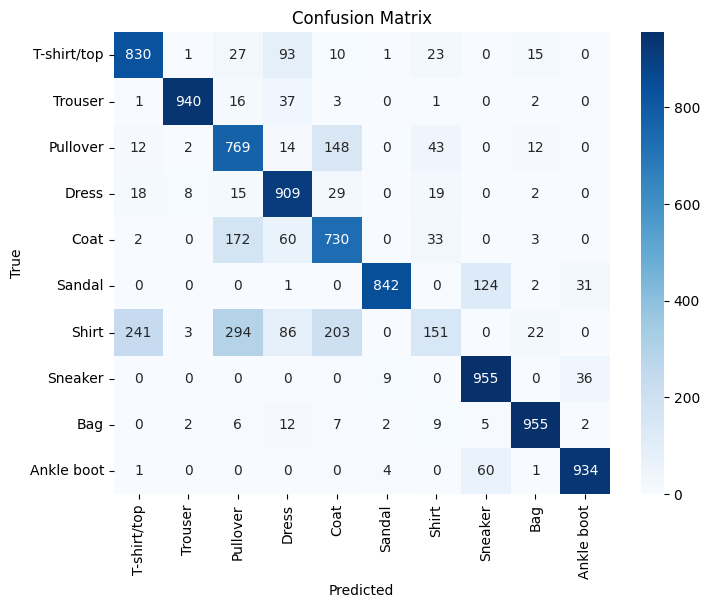

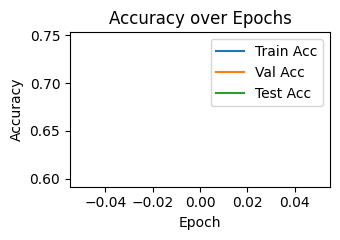

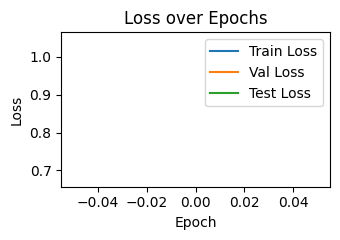


🕒 Runtime Summary
Total Training Time     : 197.11 seconds
Average Epoch Time      : 197.11 seconds
Inference Time / Sample : 0.93 ms
Early Stopping Epoch    : 1
